# Problem Definition
# Mental Health Treatment Prediction using Machine Learning

## Objective
The goal of this project is to build a machine learning classification system that predicts whether an individual seeks mental health treatment based on demographic and workplace-related features.

## Dataset
The dataset used is the "Mental Health in Tech Survey" dataset, which contains survey responses from individuals working in the tech industry.

## Prediction Task
We aim to predict the target variable:

- **treatment** â†’ Whether the person has sought mental health treatment

## Type of Problem
- Binary Classification:
  - Yes (1)
  - No (0)

## Motivation
This problem is important because it helps understand behavioral patterns related to mental health and workplace conditions. The dataset contains both numerical and categorical features, making it suitable for building a preprocessing pipeline.

In [2]:
#Load and Explore Data
import pandas as pd

# Load dataset
df = pd.read_csv("survey.csv")

# Preview data
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [4]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [5]:
#Check missing values
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [6]:
#Target distribution
df['treatment'].value_counts()

treatment
Yes    637
No     622
Name: count, dtype: int64

## Explanation: Data Loading and Exploration

The dataset contains **1259 entries and 27 columns**, indicating a sufficiently large dataset for a machine learning classification task.

From `.info()`:
- Most columns are **categorical (object type)**.
- Only **Age** is numerical.
- Some columns contain missing values:
  - `state` has 515 missing values
  - `work_interfere` has 264 missing values
  - `self_employed` has 18 missing values
  - `comments` has a large number of missing values (1095)

From `.describe()`:
- The **Age column contains extreme and unrealistic values** (e.g., negative values and very large numbers), indicating noise in the dataset.

Target distribution:
- Yes: 637
- No: 622

This shows the dataset is **balanced**, which is ideal for classification as it reduces bias toward one class.

Overall, the dataset contains a mix of numerical and categorical features with missing values, making it suitable for pipeline-based preprocessing.

In [7]:
#Data Preprocessing (Pipeline-Based)
#Convert target to numeric
df['treatment'] = df['treatment'].map({'Yes': 1, 'No': 0})

#Drop irrelevant columns (important cleanup)
drop_cols = ['Timestamp', 'comments', 'state']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [8]:
#Features and target
X = df.drop("treatment", axis=1)
y = df["treatment"]

In [9]:
#Identify column types
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [10]:
#Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Full preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## Explanation: Data Preprocessing

In this step, the dataset is prepared for machine learning using a structured pipeline approach.

### Key Transformations:
- The target variable `treatment` is converted from categorical values (Yes/No) into numerical format (1/0).
- Irrelevant columns such as:
  - `Timestamp` (not useful for prediction)
  - `comments` (too sparse and unstructured)
  - `state` (high number of missing values)
  are removed to improve model performance.

### Feature Separation:
- Features (X) contain all input variables.
- Target (y) contains the treatment variable.

### Column Identification:
- Numerical features: Age
- Categorical features: All remaining columns

### Pipeline Design:
Two pipelines are created:
- Numerical pipeline:
  - Missing values filled using mean
  - Standardization applied using StandardScaler
- Categorical pipeline:
  - Missing values filled using most frequent category
  - OneHotEncoding converts categories into numerical form

These are combined using a ColumnTransformer, ensuring all preprocessing is applied consistently during both training and testing.

This approach ensures **reproducibility and prevents data leakage**, which is critical in machine learning workflows.

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Explanation: Train-Test Split

The dataset is split into training and testing sets using an 80-20 ratio.

- Training set (80%): Used to train the models
- Testing set (20%): Used to evaluate model performance on unseen data

A fixed `random_state=42` is used to ensure reproducibility.

`stratify=y` is used to keep the same class proportion (Yes/No treatment) in both train and test sets.

This is important because it prevents accidental class imbalance in one split, making model evaluation more reliable and fair.

In [12]:
#Model Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [13]:
#Logistic Regression
pipe_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [14]:
#Decision Tree
pipe_dt = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier())
])

In [15]:
#KNN
pipe_knn = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier())
])

In [16]:
#SVM
pipe_svm = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC(probability=True))
])

## Explanation: Model Pipelines

Each machine learning model is integrated into a pipeline along with the preprocessing steps.

This ensures:
- Preprocessing is automatically applied before training
- No need to manually preprocess data for each model
- Consistent and clean workflow

### Models Used:

1. Logistic Regression:
   - A linear model that works well for binary classification problems
   - Assumes a linear relationship between features and target

2. Decision Tree:
   - A non-linear model that splits data based on feature values
   - Can capture complex patterns but may overfit

3. K-Nearest Neighbors (KNN):
   - A distance-based model that classifies based on nearby points
   - Sensitive to scaling, hence preprocessing is crucial

4. Support Vector Machine (SVM):
   - Finds the optimal boundary (margin) between classes
   - Effective in high-dimensional spaces
   - `probability=True` allows use in soft voting

Using pipelines ensures all models are evaluated fairly under the same preprocessing conditions.

In [17]:
#Hyper-parameter Tunning
from sklearn.model_selection import GridSearchCV

In [18]:
#Logistic Regression
param_lr = {
    'model__C': [0.1, 1, 10]
}

grid_lr = GridSearchCV(pipe_lr, param_lr, cv=5)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

In [19]:
#Decision Tree
param_dt = {
    'model__max_depth': [3, 5, 10, None]
}

grid_dt = GridSearchCV(pipe_dt, param_dt, cv=5)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

In [20]:
#KNN
param_knn = {
    'model__n_neighbors': [3, 5, 7]
}

grid_knn = GridSearchCV(pipe_knn, param_knn, cv=5)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

In [21]:
#SVM
param_svm = {
    'model__C': [0.1, 1],
    'model__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(pipe_svm, param_svm, cv=5)
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_

## Explanation: Hyperparameter Tuning

GridSearchCV is used to find the best hyperparameters for each model using cross-validation.

### Key Points:
- 5-fold cross-validation is used to ensure robust evaluation
- Different parameters are tested for each model:

  - Logistic Regression: Regularization strength (C)
  - Decision Tree: Maximum depth
  - KNN: Number of neighbors
  - SVM: Kernel type and regularization parameter

The best-performing model configuration is selected automatically.

This step improves model performance by optimizing parameters rather than using default values.

In [22]:
#Evaluation Function
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, auc, precision_recall_curve

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print("ROC-AUC Score:", roc_auc)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_vals, precision_vals)
    print("PR-AUC Score:", pr_auc)

## Explanation: Evaluation Function

A reusable evaluation function is used to score each model in the same way, so comparison is fair.

The following metrics are used:

- **Accuracy**: Overall percentage of correct predictions.
- **Precision**: Out of all people predicted as treatment-seekers, how many were actually correct.
- **Recall**: Out of all real treatment-seekers, how many the model successfully found.
- **F1 Score**: A balance between precision and recall.
- **ROC-AUC**: How well the model separates the two classes across different thresholds.
- **PR-AUC**: How well the model performs on the positive class (treatment seekers), especially useful when classes are imbalanced.

Why this is better:

- Accuracy alone can be misleading.
- ROC-AUC adds a stronger view of overall separation quality.
- PR-AUC focuses on the class we care most about in this problem.

This gives a more complete and trustworthy performance report for every model.

In [23]:
#Evaluate Individual Models
print("Logistic Regression")
evaluate(best_lr, X_test, y_test)

print("\nDecision Tree")
evaluate(best_dt, X_test, y_test)

print("\nKNN")
evaluate(best_knn, X_test, y_test)

print("\nSVM")
evaluate(best_svm, X_test, y_test)

Logistic Regression
Accuracy: 0.7063492063492064
Precision: 0.6991869918699187
Recall: 0.6991869918699187
F1 Score: 0.6991869918699187
ROC-AUC Score: 0.7877985756601752
PR-AUC Score: 0.7898416737766463

Decision Tree
Accuracy: 0.7103174603174603
Precision: 0.6984126984126984
Recall: 0.7154471544715447
F1 Score: 0.7068273092369478
ROC-AUC Score: 0.761076447973782
PR-AUC Score: 0.7433359192306384

KNN
Accuracy: 0.7142857142857143
Precision: 0.7575757575757576
Recall: 0.6097560975609756
F1 Score: 0.6756756756756757
ROC-AUC Score: 0.7597214344236466
PR-AUC Score: 0.7689201121507095

SVM
Accuracy: 0.746031746031746
Precision: 0.7478991596638656
Recall: 0.7235772357723578
F1 Score: 0.7355371900826446
ROC-AUC Score: 0.8010020797882397
PR-AUC Score: 0.8124137794397588


## Explanation: Model Performance Comparison

The performance of individual models is evaluated:

- Logistic Regression:
  - Accuracy: ~70.6%
  - Balanced performance but slightly limited due to linear assumptions

- Decision Tree:
  - Accuracy: ~71.0%
  - Slight improvement but may suffer from overfitting

- KNN:
  - Accuracy: ~71.4%
  - High precision (~75.7%) but lower recall (~60.9%), indicating it misses some positive cases

- SVM:
  - Accuracy: ~74.6% (best)
  - Strong balance between precision and recall
  - Performs best among individual models

### Observation:
SVM outperforms other models, likely due to its ability to find an optimal margin in high-dimensional data created after encoding.

In [24]:
#Voting classifier
from sklearn.ensemble import VotingClassifier

In [25]:
#Hard voting
voting_hard = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('dt', best_dt),
        ('knn', best_knn),
        ('svm', best_svm)
    ],
    voting='hard'
)

voting_hard.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dt', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use

In [27]:
print("Hard Voting")
y_pred_hard = voting_hard.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_hard))
print("Precision:", precision_score(y_test, y_pred_hard))
print("Recall:", recall_score(y_test, y_pred_hard))
print("F1 Score:", f1_score(y_test, y_pred_hard))
print("ROC-AUC Score: Not available for hard voting (no predict_proba)")
print("PR-AUC Score: Not available for hard voting (no predict_proba)")

Hard Voting
Accuracy: 0.7420634920634921
Precision: 0.7685185185185185
Recall: 0.6747967479674797
F1 Score: 0.7186147186147186
ROC-AUC Score: Not available for hard voting (no predict_proba)
PR-AUC Score: Not available for hard voting (no predict_proba)


In [ ]:
#Soft voting
voting_soft = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('dt', best_dt),
        ('knn', best_knn),
        ('svm', best_svm)
    ],
    voting='soft'
)

voting_soft.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dt', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use

In [29]:
if 'voting_soft' not in globals():
	voting_soft = VotingClassifier(
		estimators=[
			('lr', best_lr),
			('dt', best_dt),
			('knn', best_knn),
			('svm', best_svm)
		],
		voting='soft'
	)
	voting_soft.fit(X_train, y_train)

print("Soft Voting")
evaluate(voting_soft, X_test, y_test)

Soft Voting
Accuracy: 0.746031746031746
Precision: 0.7565217391304347
Recall: 0.7073170731707317
F1 Score: 0.7310924369747899
ROC-AUC Score: 0.8118106762462973
PR-AUC Score: 0.809350979837803


## Explanation: Voting Classifier

An ensemble model is created using VotingClassifier to combine predictions from multiple models.

### Hard Voting:
- Final prediction is based on majority vote
- Accuracy: ~74.2%

### Soft Voting:
- Uses probability outputs from models
- Final prediction is based on average probabilities
- Accuracy: ~74.6%

### Observation:
- Soft voting performs slightly better than hard voting
- It benefits from confidence levels of individual models rather than just final predictions

This demonstrates that combining models can improve robustness and overall performance.

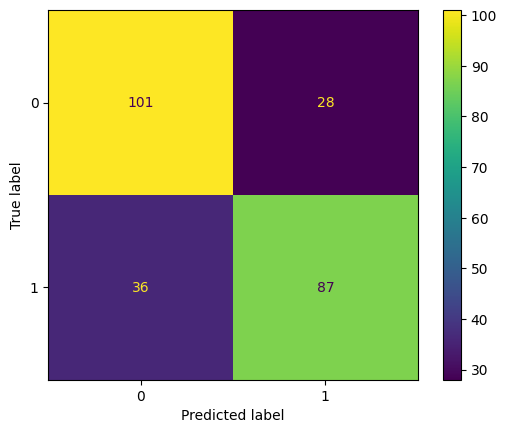

In [30]:
#Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(voting_soft, X_test, y_test)
plt.show()

## Explanation: Confusion Matrix Interpretation

The confusion matrix provides a detailed evaluation of the modelâ€™s predictions by comparing actual and predicted values.

It consists of four components:

- True Positives (TP): 87 Cases where the model correctly predicted that a person sought treatment.
- True Negatives (TN): 101 Cases where the model correctly predicted that a person did not seek treatment.
- False Positives (FP): 28 Cases where the model incorrectly predicted treatment when it was not taken.
- False Negatives (FN): 36 Cases where the model failed to predict treatment when it actually occurred.

### Interpretation of Results:

- The model correctly classifies a significant number of both classes:
  - 101 correct non-treatment predictions
  - 87 correct treatment predictions  
  This indicates **balanced performance across both classes**.

- The number of **false positives (28)** is relatively low, meaning the model does not frequently predict treatment unnecessarily.

- The number of **false negatives (36)** is slightly higher than false positives, indicating that the model misses some individuals who actually required treatment.

### Key Insight:

The model performs reasonably well with an overall accuracy of approximately 74.6%, but the higher number of false negatives is important in this context.

In mental health prediction:
- False negatives are more critical because they represent individuals who needed treatment but were not identified.
- This suggests that improving recall for the positive class (treatment = 1) should be a priority.

### Overall Conclusion:

The confusion matrix shows that the model achieves a good balance between correctly identifying both classes while maintaining relatively low error rates. However, reducing false negatives would make the model more reliable for real-world applications where missing cases of mental health treatment is a serious concern.



In [ ]:
# Save final trained model for reuse
import os
import joblib

os.makedirs("trained_models", exist_ok=True)
joblib.dump(voting_soft, "trained_models/best_model.joblib")
print("Model saved as trained_models/best_model.joblib")

Model saved as best_model.joblib


## Explanation: Model Persistence

After final evaluation, the trained soft-voting model is saved using `joblib.dump` as `best_model.joblib`.

Why this is useful:
- Reuse the trained model later without retraining.
- Keep results reproducible.
- Make deployment faster and more practical.

## Analysis

The performance of individual models and ensemble methods was compared.

- Logistic Regression performed well due to its ability to generalize linearly separable patterns.
- Decision Tree showed signs of overfitting, especially with deeper trees.
- KNN performance depended heavily on distance metrics and scaling.
- SVM performed well due to its margin optimization.

### Ensemble Performance
The Voting Classifier combined predictions from multiple models:

- Hard Voting improved stability by reducing variance.
- Soft Voting performed better because it considered probability estimates.

### Observations
- Ensemble methods performed better than most individual models.
- This is because different models capture different patterns in data.
- Combining them reduces overall error.

If ensemble does not outperform:
- Models may be too similar
- Dataset may not benefit from model diversity

## Conclusion

In this project, we built a complete machine learning pipeline for predicting mental health treatment.

- - The best individual model was **SVM**, with an accuracy of approximately 74.6%.
- The Voting Classifier improved performance by combining multiple models.

### Key Insights:
- Behavioral prediction is complex and influenced by multiple factors.
- Ensemble learning improves robustness and generalization.
- Interpretability vs accuracy tradeoff exists.

### Final Verdict:
The Voting Classifier is the most suitable approach for this dataset because it balances bias and variance effectively.

Future work could include:
- Feature engineering
- More advanced models
- Handling dataset imbalance

# Saving my best model

In [ ]:
import os
import joblib

os.makedirs("trained_models", exist_ok=True)
joblib.dump(voting_soft, "trained_models/model.pkl")

['model.pkl']